# Sample selection 

In [1]:
import pandas as pd
import subsetmask as sm
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# %% setting paths
MAIN_DIR_NAME = "proseg_slides_meta"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

We use the metadata flatfile

In [4]:
# setting paths
slide_number = '01'
meta_path = MAIN_DIR / f'SLIDE{slide_number}_meta.tsv'

In [ ]:
# run this to activate qt (linux systems)
%gui qt

## Slide 1

In [7]:
meta = pd.read_csv(meta_path, sep='\t', index_col=0)

# remove column sample_name if it was already added
if 'sample_name' in meta.columns:
    meta = meta.drop(columns=['sample_name'])

# check columns
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale
0,0,c_1_194_1363,617.70280,1390.7644,0.198427,8,35.75,198.0,1.0
1,1,c_1_194_1366,635.93335,1390.4218,0.366667,6,7.50,70.0,1.0
2,2,c_1_194_1247,515.02740,1475.3912,0.253425,8,36.50,236.0,1.0
3,3,c_1_194_1253,521.21950,1473.5997,0.262195,5,20.50,152.0,1.0
4,4,c_1_194_1220,521.70514,1488.5975,0.263889,8,29.25,180.0,1.0


In [27]:
# add slide_ID column
meta['slide_ID'] = f'SLIDE{slide_number}'

# add a cell_id column with slide_name + cell
meta['cell_id'] =  meta['slide_ID'] + '_' + meta['cell'].astype(str)
meta.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,sample_name,cell_id
0,0,c_1_194_1363,617.70280,1390.7644,0.198427,8,35.75,198.0,1.0,SLIDE01,PWCF01_2,SLIDE01_0
1,1,c_1_194_1366,635.93335,1390.4218,0.366667,6,7.50,70.0,1.0,SLIDE01,PWCF01_2,SLIDE01_1
2,2,c_1_194_1247,515.02740,1475.3912,0.253425,8,36.50,236.0,1.0,SLIDE01,PWCF01_2,SLIDE01_2
3,3,c_1_194_1253,521.21950,1473.5997,0.262195,5,20.50,152.0,1.0,SLIDE01,PWCF01_2,SLIDE01_3
4,4,c_1_194_1220,521.70514,1488.5975,0.263889,8,29.25,180.0,1.0,SLIDE01,PWCF01_2,SLIDE01_4


In [10]:
# create the image for slide1
slide = sm.Image(metadata_df=meta, 
                  images_col='slide_ID',
                  image_name=f'SLIDE{slide_number}',
                  x_col = 'centroid_x',
                  y_col = 'centroid_y',)

# add store image method
slide.store_image(group_col=None, 
                   figsize=(30,50),
                   dpi=300, 
                   dot_size=2,
                   cmap='tab20')

/Users/robin.carvajal/miniforge3/envs/subsetmask/lib/python3.10/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (135000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


array([[[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       ...,

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        ...,
        [255, 255, 255, 255],
        [255, 255, 255, 255],
        [255, 255, 255, 255]],

       [[255

In [11]:
# launches napari with the generated image, ready for selection
slide.draw_labels()

<Labels layer 'Mask' at 0x34c406350>

In [12]:
# without closing napari we run this line to save the annotations
slide.save_annotations(ann_col_name="sample_name")

# we change our annotations for something more meaningful
map = {
    "label_1": "PWCF01_1",
    "label_2": "PWCF01_2"
}

slide.rename_annotations(ann_col_name="sample_name", mapping_dict=map)

# we extract the annotated df from the object
annotated_meta_slide = slide.annotated_metadata_df

# check the annotated metadata
annotated_meta_slide.head()

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,sample_name
0,0,c_1_194_1363,617.70280,1390.7644,0.198427,8,35.75,198.0,1.0,SLIDE01,PWCF01_2
1,1,c_1_194_1366,635.93335,1390.4218,0.366667,6,7.50,70.0,1.0,SLIDE01,PWCF01_2
2,2,c_1_194_1247,515.02740,1475.3912,0.253425,8,36.50,236.0,1.0,SLIDE01,PWCF01_2
3,3,c_1_194_1253,521.21950,1473.5997,0.262195,5,20.50,152.0,1.0,SLIDE01,PWCF01_2
4,4,c_1_194_1220,521.70514,1488.5975,0.263889,8,29.25,180.0,1.0,SLIDE01,PWCF01_2


Checking that it worked

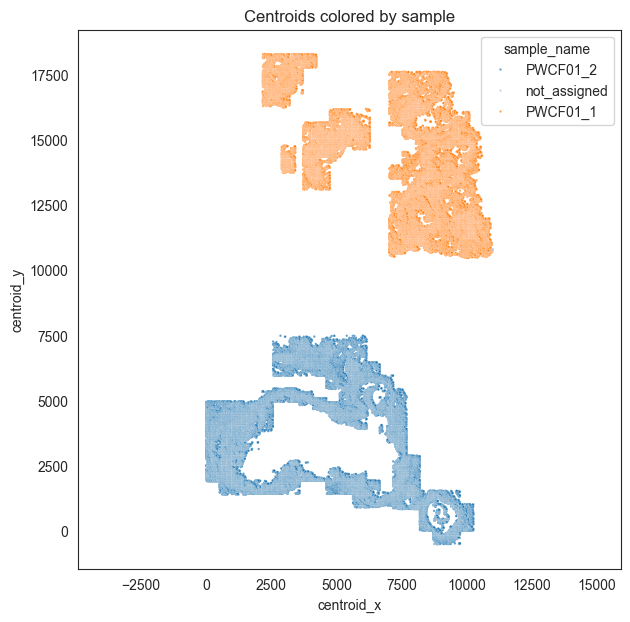

In [14]:
# scater plot using matplot lib
plt.figure(figsize=(7, 7))
sns.set_style("white")
sns.scatterplot(
    data=annotated_meta_slide,
    x="centroid_x",
    y="centroid_y",
    hue="sample_name",        # or "library_id", etc.
    s=3,
    alpha=0.7,
    palette="tab20"      # or any seaborn/matplotlib palette
)
plt.axis("equal")
plt.title("Centroids colored by sample")
plt.show()

In [15]:
annotated_meta_slide.groupby(["slide_ID", "sample_name"]).size().reset_index(name="count")

,slide_ID,sample_name,count
0,SLIDE01,PWCF01_1,178136
1,SLIDE01,PWCF01_2,198349
2,SLIDE01,not_assigned,9


In [25]:
# Save the annotated metadata with sample names
annotated_meta_slide.to_csv(meta_path, index=False)

In [26]:
# check if the saved file is correct
meta = pd.read_csv(meta_path)
meta

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,slide_ID,sample_name,cell_id
0,0,c_1_194_1363,617.70280,1390.7644,0.198427,8,35.75,198.0,1.0,SLIDE01,PWCF01_2,SLIDE01_0
1,1,c_1_194_1366,635.93335,1390.4218,0.366667,6,7.50,70.0,1.0,SLIDE01,PWCF01_2,SLIDE01_1
2,2,c_1_194_1247,515.02740,1475.3912,0.253425,8,36.50,236.0,1.0,SLIDE01,PWCF01_2,SLIDE01_2
3,3,c_1_194_1253,521.21950,1473.5997,0.262195,5,20.50,152.0,1.0,SLIDE01,PWCF01_2,SLIDE01_3
4,4,c_1_194_1220,521.70514,1488.5975,0.263889,8,29.25,180.0,1.0,SLIDE01,PWCF01_2,SLIDE01_4
...,...,...,...,...,...,...,...,...,...,...,...,...
376489,376489,c_1_39_185,9276.15300,17351.6020,0.849490,6,12.25,98.0,1.0,SLIDE01,PWCF01_1,SLIDE01_376489
376490,376490,c_1_39_166,9267.05700,17369.0430,0.776210,3,31.00,180.0,1.0,SLIDE01,PWCF01_1,SLIDE01_376490
376491,376491,c_1_39_98,9224.70300,17435.5060,0.763513,9,18.50,136.0,1.0,SLIDE01,PWCF01_1,SLIDE01_376491
376492,376492,c_1_39_19,9224.04700,17547.0000,0.858333,3,37.50,176.0,1.0,SLIDE01,PWCF01_1,SLIDE01_376492
